Found 625


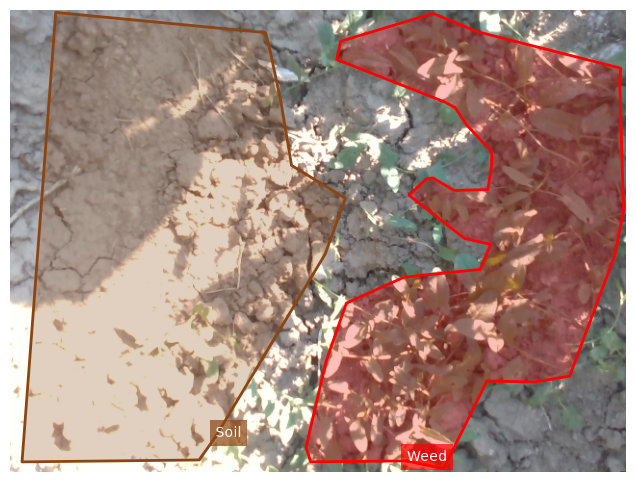

In [ ]:
#Author: Atiye Buker. Purpose: clean up JSON file
import os
import json

json_file_path = 'via_project_24Apr2025_15h0m_json (5).json'
image_folder = '/mnt/c/Users/buker/Downloads/SURP2026/Annotated/September 10th and Aug, 2021'

with open(json_file_path, 'r') as file:
    segmentation = json.load(file)

#the files we actually have
actual_files = os.listdir(image_folder)

cleaned_segmentation = {}
match_count = 0

for img_key, img_data in segmentation.items():
    base_name = img_key.split('.png')[0] + '.png' #file contains some random numbers, so just get the base 
    
    #ssee if this exists in the dataset
    if base_name in actual_files:
        cleaned_segmentation[img_key] = img_data
        match_count += 1

#make new JSON file with the existing entries
with open('cleaned_via_project.json', 'w') as outfile:
    json.dump(cleaned_segmentation, outfile, indent=4)

#print how many there are
print(f"Found {match_count}")


cleaned_keys = list(cleaned_segmentation.keys())

img_id = 400
img_key = cleaned_keys[img_id]
img_data = cleaned_segmentation[img_key]


filename = img_key.split(".png")[0] + ".png"
filename = filename.split("/")[-1]




img_path = os.path.join("/mnt/c/Users/buker/Downloads/SURP2026/Annotated/September 10th and Aug, 2021", filename)
image = np.array(Image.open(img_path))
plt.figure(figsize=(8, 6))
plt.imshow(image)


colors = {
    "Chili": "green",
    "Soil": "saddlebrown",
    "Weed": "red"
}
default_color = "gray"


for i, region in enumerate(img_data["regions"]):


    label = region["region_attributes"].get("names", "object")


    shape = region["shape_attributes"]


    if shape["name"] == "polygon":
           x = shape["all_points_x"]
           y = shape["all_points_y"]


           color = colors.get(label, "gray")


           plt.plot(
               x + [x[0]],
               y + [y[0]],
               color=color,
               linewidth=2
            )


           plt.fill(
               x,
               y,
               color=color,
               alpha=0.25
            )


           plt.text(
      x[0],
      y[0],
      label,
      color='white',
      fontsize=10,
      bbox=dict(facecolor=color, alpha=0.7, edgecolor='none')
           )


plt.axis("off")
plt.show()
